# 06. Final Figures and Tables

This notebook consolidates the **revised main-analysis results** into manuscript/reviewer-ready tables and figures.

It does not perform new hypothesis testing. It summarizes outputs from:

- 02 Differential Expression
- 03 miRNA–mRNA Integration
- 04 GO Enrichment
- 05 Cell Composition

The confirmatory and exploratory results are kept explicitly separate.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures" / "final"
TABLES_DIR = RESULTS_DIR / "final_tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("RESULTS_DIR  =", RESULTS_DIR)
print("FIGURES_DIR  =", FIGURES_DIR)
print("TABLES_DIR   =", TABLES_DIR)


PROJECT_ROOT = /Users/jihopark/Desktop/MCDA_revision_final
RESULTS_DIR  = /Users/jihopark/Desktop/MCDA_revision_final/results
FIGURES_DIR  = /Users/jihopark/Desktop/MCDA_revision_final/figures/final
TABLES_DIR   = /Users/jihopark/Desktop/MCDA_revision_final/results/final_tables


## 1. Load finalized analysis outputs

In [2]:
FILES = {
    "DE summary": RESULTS_DIR / "DE_summary.csv",
    "mRNA full": RESULTS_DIR / "mRNA_limma_full_results.csv",
    "miRNA full": RESULTS_DIR / "miRNA_limma_full_results.csv",
    "mRNA FDR": RESULTS_DIR / "mRNA_FDR_significant.csv",
    "miRNA FDR": RESULTS_DIR / "miRNA_FDR_significant.csv",
    "DEG exploratory": RESULTS_DIR / "DEG_exploratory_candidates.csv",
    "DEM exploratory": RESULTS_DIR / "DEM_exploratory_candidates.csv",
    "Integration summary": RESULTS_DIR / "miRNA_mRNA_integration_summary.csv",
    "Integration all": RESULTS_DIR / "miRNA_mRNA_all_supported_pairs.csv",
    "Integration multi-DB": RESULTS_DIR / "miRNA_mRNA_multi_database_pairs.csv",
    "Integration anti": RESULTS_DIR / "miRNA_mRNA_anti_correlated_pairs.csv",
    "GO": RESULTS_DIR / "GO_enrichment_full_results.csv",
    "Deconvolution summary": RESULTS_DIR / "deconvolution_method_summary.csv",
    "NNLS stats": RESULTS_DIR / "deconvolution_within_pair_stats_NNLS.csv",
    "Marker stats": RESULTS_DIR / "deconvolution_within_pair_stats_marker.csv",
    "ssGSEA stats": RESULTS_DIR / "deconvolution_within_pair_stats_ssgsea.csv",
}

loaded = {}
for name, path in FILES.items():
    if path.exists():
        loaded[name] = pd.read_csv(path)
        print("FOUND  ", name, "->", path.name)
    else:
        print("MISSING", name, "->", path.name)

required = [
    "DE summary", "mRNA full", "miRNA full",
    "DEG exploratory", "DEM exploratory",
    "Integration summary", "GO", "Deconvolution summary"
]
missing_required = [x for x in required if x not in loaded]
if missing_required:
    raise FileNotFoundError(
        f"Missing required finalized outputs: {missing_required}"
    )


FOUND   DE summary -> DE_summary.csv
FOUND   mRNA full -> mRNA_limma_full_results.csv
FOUND   miRNA full -> miRNA_limma_full_results.csv
FOUND   mRNA FDR -> mRNA_FDR_significant.csv
FOUND   miRNA FDR -> miRNA_FDR_significant.csv
FOUND   DEG exploratory -> DEG_exploratory_candidates.csv
FOUND   DEM exploratory -> DEM_exploratory_candidates.csv
FOUND   Integration summary -> miRNA_mRNA_integration_summary.csv
FOUND   Integration all -> miRNA_mRNA_all_supported_pairs.csv
FOUND   Integration multi-DB -> miRNA_mRNA_multi_database_pairs.csv
FOUND   Integration anti -> miRNA_mRNA_anti_correlated_pairs.csv
FOUND   GO -> GO_enrichment_full_results.csv
FOUND   Deconvolution summary -> deconvolution_method_summary.csv
FOUND   NNLS stats -> deconvolution_within_pair_stats_NNLS.csv
FOUND   Marker stats -> deconvolution_within_pair_stats_marker.csv
FOUND   ssGSEA stats -> deconvolution_within_pair_stats_ssgsea.csv


## 2. Final result overview

In [3]:
de_summary = loaded["DE summary"]
integration_summary = loaded["Integration summary"]
go = loaded["GO"]
deconv_summary = loaded["Deconvolution summary"]

overview = pd.DataFrame([
    {
        "Analysis": "mRNA differential expression",
        "Confirmatory result": f'{int(de_summary.loc[de_summary["dataset"]=="mRNA","n_FDR_lt_0.05"].iloc[0])} BH-FDR-significant',
        "Exploratory / sensitivity result": f'{int(de_summary.loc[de_summary["dataset"]=="mRNA","n_exploratory_candidates"].iloc[0])} exploratory candidates'
    },
    {
        "Analysis": "miRNA differential expression",
        "Confirmatory result": f'{int(de_summary.loc[de_summary["dataset"]=="miRNA","n_FDR_lt_0.05"].iloc[0])} BH-FDR-significant',
        "Exploratory / sensitivity result": f'{int(de_summary.loc[de_summary["dataset"]=="miRNA","n_exploratory_candidates"].iloc[0])} exploratory candidates'
    },
    {
        "Analysis": "miRNA–mRNA integration",
        "Confirmatory result": "No confirmatory regulatory claim",
        "Exploratory / sensitivity result": f'{int(integration_summary.loc[integration_summary["Metric"]=="All database-supported pairs","Value"].iloc[0])} database-supported pairs'
    },
    {
        "Analysis": "GO enrichment",
        "Confirmatory result": f'{int((go["adj.P.Val"] < 0.05).sum())} BH-FDR-significant GO terms',
        "Exploratory / sensitivity result": "Nominal GO patterns only"
    },
    {
        "Analysis": "Cell composition",
        "Confirmatory result": "Sensitivity analysis only",
        "Exploratory / sensitivity result": f'{int(deconv_summary["n_P_lt_0_05"].sum())} nominal P<0.05 cell-type results across 3 methods'
    }
])

display(overview)


,Analysis,Confirmatory result,Exploratory / sensitivity result
0,mRNA differential expression,0 BH-FDR-significant,114 exploratory candidates
1,miRNA differential expression,1 BH-FDR-significant,30 exploratory candidates
2,miRNA–mRNA integration,No confirmatory regulatory claim,26 database-supported pairs
3,GO enrichment,0 BH-FDR-significant GO terms,Nominal GO patterns only
4,Cell composition,Sensitivity analysis only,0 nominal P<0.05 cell-type results across 3 me...


## 3. Table 1 — Differential-expression summary

In [4]:
table_de = de_summary.copy()
table_de.columns = [
    "Dataset",
    "Features tested",
    "BH-FDR < 0.05",
    "Exploratory candidates",
    "Minimum BH-FDR"
]

display(table_de)

table_de.to_csv(
    TABLES_DIR / "Table_DE_summary.csv",
    index=False
)


,Dataset,Features tested,BH-FDR < 0.05,Exploratory candidates,Minimum BH-FDR
0,mRNA,29383,0,114,0.965865
1,miRNA,4422,1,30,0.001795


## 4. Table 2 — FDR-significant features

In [5]:
fdr_frames = []

if "miRNA FDR" in loaded and not loaded["miRNA FDR"].empty:
    x = loaded["miRNA FDR"].copy()
    x.insert(0, "Dataset", "miRNA")
    fdr_frames.append(x)

if "mRNA FDR" in loaded and not loaded["mRNA FDR"].empty:
    x = loaded["mRNA FDR"].copy()
    x.insert(0, "Dataset", "mRNA")
    fdr_frames.append(x)

fdr_features = (
    pd.concat(fdr_frames, ignore_index=True)
    if fdr_frames
    else pd.DataFrame()
)

display(fdr_features)

fdr_features.to_csv(
    TABLES_DIR / "Table_FDR_significant_features.csv",
    index=False
)


,Dataset,miRNA,logFC,FC_abs,diff_MZ1,diff_MZ2,diff_MZ3,t_moderated,P.Value,adj.P.Val,B,consistent_direction,FDR_significant,exploratory_candidate
0,miRNA,hsa-miR-1292-5p,-1.66582,3.172939,-1.62401,-1.58455,-1.7889,-13.947912,4.060170e-07,0.001795,3.584017,True,True,True


## 5. Figure 1 — Differential-expression volcano plots

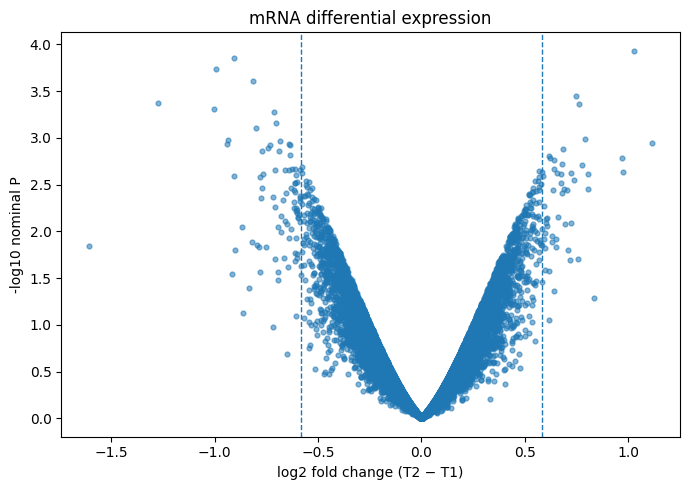

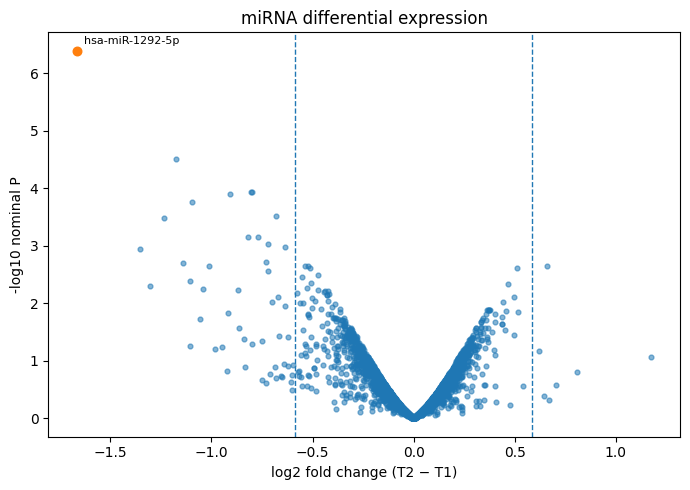

In [6]:
def volcano(df, feature_col, title, outfile):
    d = df.copy()
    d["minus_log10_p"] = -np.log10(
        d["P.Value"].clip(lower=np.finfo(float).tiny)
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(
        d["logFC"],
        d["minus_log10_p"],
        s=12,
        alpha=0.55
    )

    # Mark BH-FDR-significant features separately.
    sig = d[d["adj.P.Val"] < 0.05]
    if not sig.empty:
        ax.scatter(
            sig["logFC"],
            sig["minus_log10_p"],
            s=38
        )

        for _, r in sig.iterrows():
            ax.annotate(
                str(r[feature_col]),
                (r["logFC"], r["minus_log10_p"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8
            )

    ax.axvline(np.log2(1.5), linestyle="--", linewidth=1)
    ax.axvline(-np.log2(1.5), linestyle="--", linewidth=1)
    ax.set_xlabel("log2 fold change (T2 − T1)")
    ax.set_ylabel("-log10 nominal P")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(outfile, dpi=300)
    plt.show()

volcano(
    loaded["mRNA full"],
    "Gene",
    "mRNA differential expression",
    FIGURES_DIR / "Figure_DE_mRNA_volcano.png"
)

volcano(
    loaded["miRNA full"],
    "miRNA",
    "miRNA differential expression",
    FIGURES_DIR / "Figure_DE_miRNA_volcano.png"
)


## 6. Table 3 — miRNA–mRNA integration

In [7]:
integration_all = loaded.get(
    "Integration all",
    pd.DataFrame()
)
integration_multi = loaded.get(
    "Integration multi-DB",
    pd.DataFrame()
)
integration_anti = loaded.get(
    "Integration anti",
    pd.DataFrame()
)

print("All supported pairs:", len(integration_all))
print(">=2 DB supported:", len(integration_multi))
print("Anti-correlated:", len(integration_anti))

display(integration_summary)
display(integration_multi)
display(integration_anti)

integration_summary.to_csv(
    TABLES_DIR / "Table_miRNA_mRNA_integration_summary.csv",
    index=False
)

integration_multi.to_csv(
    TABLES_DIR / "Table_miRNA_mRNA_multi_database_pairs.csv",
    index=False
)

integration_anti.to_csv(
    TABLES_DIR / "Table_miRNA_mRNA_anti_correlated_pairs.csv",
    index=False
)


All supported pairs: 26
>=2 DB supported: 3
Anti-correlated: 3


,Metric,Value
0,All database-supported pairs,26
1,Pairs involving FDR-significant miRNA,0
2,Pairs supported by >=2 databases,3
3,Anti-correlated pairs,3
4,Pairs with >=2 DB support AND anti-correlation,0


,miRNA,Gene,miRDB,TargetScan,miRTarBase,n_databases,FDR_significant_miRNA,miRNA_logFC,miRNA_FDR,mRNA_logFC,mRNA_FDR,expression_relationship
0,hsa-miR-128-3p,EIF5,False,True,True,2,False,-1.174363,0.069791,-0.60897,0.965865,same-direction
1,hsa-miR-128-3p,MOB1B,False,True,True,2,False,-1.174363,0.069791,-0.81865,0.965865,same-direction
2,hsa-miR-328-3p,HIST1H4D,False,True,True,2,False,-1.094243,0.129738,-1.00372,0.965865,same-direction


,miRNA,Gene,miRDB,TargetScan,miRTarBase,n_databases,FDR_significant_miRNA,miRNA_logFC,miRNA_FDR,mRNA_logFC,mRNA_FDR,expression_relationship
0,hsa-miR-128-3p,CISD1,False,False,True,1,False,-1.174363,0.069791,0.616583,0.965865,anti-correlated
1,hsa-miR-148b-3p,TEX13A,False,False,True,1,False,-0.908403,0.109901,0.656873,0.965865,anti-correlated
2,hsa-miR-6779-5p,CBY3,False,False,True,1,False,-0.681383,0.178395,0.601470,0.965865,anti-correlated


## 7. Figure 2 — Integration evidence summary

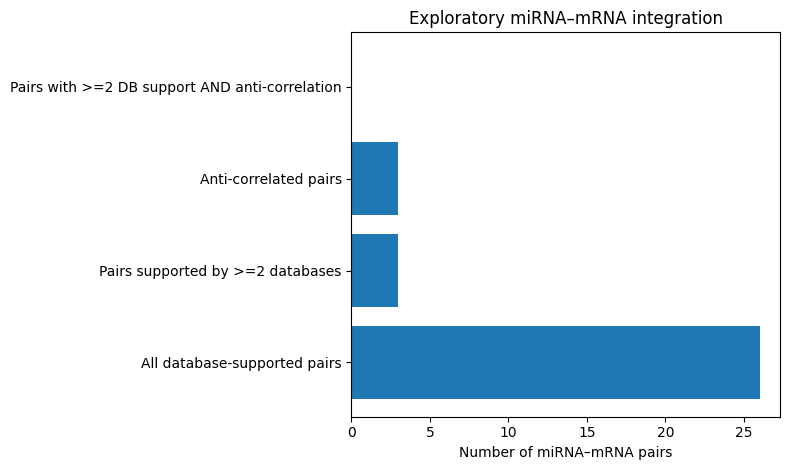

In [8]:
metrics = [
    "All database-supported pairs",
    "Pairs supported by >=2 databases",
    "Anti-correlated pairs",
    "Pairs with >=2 DB support AND anti-correlation"
]

vals = []
labels = []

for metric in metrics:
    row = integration_summary[
        integration_summary["Metric"] == metric
    ]
    if not row.empty:
        labels.append(metric)
        vals.append(int(row["Value"].iloc[0]))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(labels, vals)
ax.set_xlabel("Number of miRNA–mRNA pairs")
ax.set_title("Exploratory miRNA–mRNA integration")
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "Figure_miRNA_mRNA_integration_summary.png",
    dpi=300
)
plt.show()


## 8. Table 4 — Top revised GO signals

In [9]:
top_go = (
    go.sort_values(
        ["adj.P.Val", "P.Value"]
    )
    .head(20)
    .copy()
)

display(
    top_go[
        [
            "Ontology","GO_ID","GO_term",
            "candidate_hits","term_size",
            "P.Value","adj.P.Val","Genes"
        ]
    ]
)

top_go.to_csv(
    TABLES_DIR / "Table_top_exploratory_GO_terms.csv",
    index=False
)


,Ontology,GO_ID,GO_term,candidate_hits,term_size,P.Value,adj.P.Val,Genes
0,BP,GO:0006335,DNA replication-dependent nucleosome assembly,3,31,0.000117,0.050183,CHAF1B;HIST1H4B;HIST1H4D
1,CC,GO:0000786,nucleosome,4,96,0.000217,0.050183,HIST1H2AJ;HIST1H2BL;HIST1H4B;HIST1H4D
2,BP,GO:0035574,histone H4-K20 demethylation,2,15,0.000953,0.095996,HIST1H4B;HIST1H4D
3,MF,GO:0035575,histone demethylase activity (H4-K20 specific),2,15,0.000953,0.095996,HIST1H4B;HIST1H4D
4,BP,GO:0045653,negative regulation of megakaryocyte different...,2,17,0.001229,0.095996,HIST1H4B;HIST1H4D
5,BP,GO:0006336,DNA replication-independent nucleosome assembly,2,26,0.002886,0.095996,HIST1H4B;HIST1H4D
6,BP,GO:0002731,negative regulation of dendritic cell cytokine...,1,1,0.003079,0.095996,JAK3
7,BP,GO:0045221,negative regulation of FasL biosynthetic process,1,1,0.003079,0.095996,JAK3
8,BP,GO:0060562,epithelial tube morphogenesis,1,1,0.003079,0.095996,PRKX
9,BP,GO:2000696,regulation of epithelial cell differentiation ...,1,1,0.003079,0.095996,PRKX


## 9. Figure 3 — Top exploratory GO terms

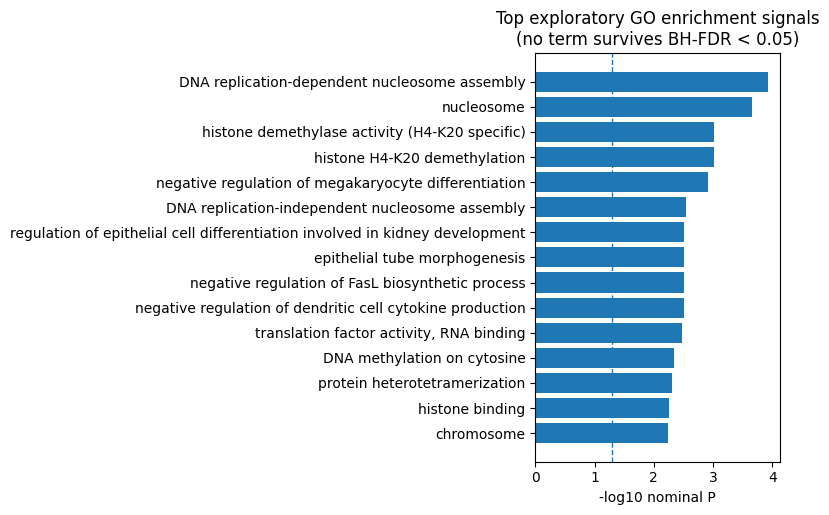

In [10]:
go_plot = (
    go.sort_values(["P.Value"])
    .head(15)
    .copy()
)

go_plot["minus_log10_p"] = -np.log10(
    go_plot["P.Value"].clip(
        lower=np.finfo(float).tiny
    )
)

go_plot = go_plot.sort_values(
    "minus_log10_p"
)

fig, ax = plt.subplots(
    figsize=(8, max(5, 0.35 * len(go_plot)))
)

ax.barh(
    go_plot["GO_term"],
    go_plot["minus_log10_p"]
)

ax.axvline(
    -np.log10(0.05),
    linestyle="--",
    linewidth=1
)

ax.set_xlabel("-log10 nominal P")
ax.set_title(
    "Top exploratory GO enrichment signals\n"
    "(no term survives BH-FDR < 0.05)"
)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "Figure_GO_top_exploratory_terms.png",
    dpi=300
)
plt.show()


## 10. Table 5 — Cell-composition sensitivity analysis

In [11]:
display(deconv_summary)

deconv_summary.to_csv(
    TABLES_DIR / "Table_cell_composition_method_summary.csv",
    index=False
)

cell_stats = []

for method_name, key in [
    ("NNLS", "NNLS stats"),
    ("Marker z-score", "Marker stats"),
    ("ssGSEA", "ssGSEA stats"),
]:
    if key in loaded:
        temp = loaded[key].copy()
        temp.insert(0, "Method", method_name)
        cell_stats.append(temp)

cell_stats_all = (
    pd.concat(cell_stats, ignore_index=True)
    if cell_stats
    else pd.DataFrame()
)

cell_stats_all.to_csv(
    TABLES_DIR / "Table_cell_composition_all_stats.csv",
    index=False
)


,Method,n_cell_types,n_P_lt_0_05,min_P,n_3pair_consistent
0,NNLS,11,0,0.25,2
1,Marker z-score,11,0,0.50,0
2,ssGSEA,11,0,0.25,1


## 11. Figure 4 — Cell-composition minimum P-values

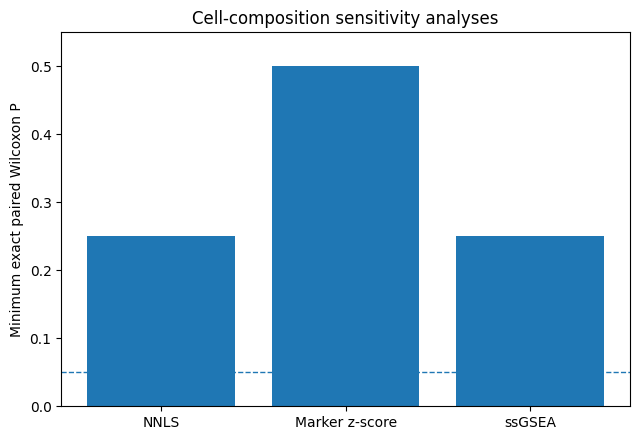

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.bar(
    deconv_summary["Method"],
    deconv_summary["min_P"]
)

ax.axhline(
    0.05,
    linestyle="--",
    linewidth=1
)

ax.set_ylabel("Minimum exact paired Wilcoxon P")
ax.set_title("Cell-composition sensitivity analyses")
ax.set_ylim(
    0,
    max(0.55, float(deconv_summary["min_P"].max()) * 1.1)
)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "Figure_cell_composition_minP.png",
    dpi=300
)
plt.show()


## 12. Final manuscript-ready statistical summary

In [13]:
final_summary = pd.DataFrame([
    {
        "Domain": "Differential expression",
        "Result": "1 miRNA and 0 mRNAs were BH-FDR significant.",
        "Interpretation": "Confirmatory"
    },
    {
        "Domain": "Exploratory DE",
        "Result": "30 miRNA and 114 mRNA exploratory candidates.",
        "Interpretation": "Hypothesis-generating"
    },
    {
        "Domain": "miRNA–mRNA integration",
        "Result": "26 database-supported pairs; 3 multi-database; 3 anti-correlated; 0 satisfying both.",
        "Interpretation": "Exploratory"
    },
    {
        "Domain": "FDR-significant miRNA integration",
        "Result": "No database-supported pair between the FDR-significant miRNA and the 114 exploratory mRNAs.",
        "Interpretation": "Negative downstream convergence"
    },
    {
        "Domain": "GO enrichment",
        "Result": "0 of 462 tested GO terms survived BH-FDR < 0.05.",
        "Interpretation": "No confirmatory functional enrichment"
    },
    {
        "Domain": "Cell composition",
        "Result": "No cell type showed nominal P < 0.05 across NNLS, marker z-score, or ssGSEA analyses.",
        "Interpretation": "Sensitivity analysis; residual confounding cannot be excluded"
    },
])

display(final_summary)

final_summary.to_csv(
    TABLES_DIR / "Table_final_statistical_summary.csv",
    index=False
)


,Domain,Result,Interpretation
0,Differential expression,1 miRNA and 0 mRNAs were BH-FDR significant.,Confirmatory
1,Exploratory DE,30 miRNA and 114 mRNA exploratory candidates.,Hypothesis-generating
2,miRNA–mRNA integration,26 database-supported pairs; 3 multi-database;...,Exploratory
3,FDR-significant miRNA integration,No database-supported pair between the FDR-sig...,Negative downstream convergence
4,GO enrichment,0 of 462 tested GO terms survived BH-FDR < 0.05.,No confirmatory functional enrichment
5,Cell composition,No cell type showed nominal P < 0.05 across NN...,Sensitivity analysis; residual confounding can...


## 13. Export consolidated Excel workbook

In [14]:
xlsx_out = TABLES_DIR / "MCDA_revised_results_tables.xlsx"

with pd.ExcelWriter(xlsx_out) as writer:
    overview.to_excel(
        writer,
        sheet_name="Overview",
        index=False
    )
    table_de.to_excel(
        writer,
        sheet_name="DE summary",
        index=False
    )
    fdr_features.to_excel(
        writer,
        sheet_name="FDR features",
        index=False
    )
    integration_summary.to_excel(
        writer,
        sheet_name="Integration summary",
        index=False
    )
    integration_multi.to_excel(
        writer,
        sheet_name="Multi-DB pairs",
        index=False
    )
    integration_anti.to_excel(
        writer,
        sheet_name="Anti-correlated",
        index=False
    )
    top_go.to_excel(
        writer,
        sheet_name="Top GO",
        index=False
    )
    deconv_summary.to_excel(
        writer,
        sheet_name="Cell composition",
        index=False
    )
    final_summary.to_excel(
        writer,
        sheet_name="Final summary",
        index=False
    )

print("Saved final workbook:")
print(xlsx_out)

print("\nFinal figures:")
for p in sorted(FIGURES_DIR.glob("*.png")):
    print(" -", p.name)


Saved final workbook:
/Users/jihopark/Desktop/MCDA_revision_final/results/final_tables/MCDA_revised_results_tables.xlsx

Final figures:
 - Figure_DE_mRNA_volcano.png
 - Figure_DE_miRNA_volcano.png
 - Figure_GO_top_exploratory_terms.png
 - Figure_cell_composition_minP.png
 - Figure_miRNA_mRNA_integration_summary.png


## Reporting notes

These outputs should preserve the evidence hierarchy used throughout the revision:

**Confirmatory**
- BH-FDR-controlled differential-expression results.

**Exploratory**
- 30 miRNA / 114 mRNA candidate analyses.
- miRNA–mRNA database integration.
- GO enrichment.

**Sensitivity**
- Cell-composition/deconvolution analyses.

Do not relabel exploratory mRNAs as statistically significant DEGs, and do not interpret database-supported miRNA–mRNA pairs as experimentally demonstrated regulation in the present samples.
